# ENG EMG - how they are different


Extract window - feature and compare the T-test for each subject








In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

from sklearn.manifold import TSNE
from mpl_toolkits.mplot3d import Axes3D

import sys
sys.path.append('../../Share/')
sys.path.append('../../Share/Manual_processing/')
sys.path.append('../Exp6 - iENG vs sENG')
import baseline, config, Model, utils, Same_with_MATLAB, Feature_info, shared_iENG_sENG

import warnings
warnings.filterwarnings('ignore')

subjects = [f"Subject {i+1}" for i in range(len(["HM", "BY", "HJ", "JI", "YC", "HR", "CS", "MJ", "XY", "BR"]))]

base_path = 'C:/Users/hml76/PycharmProjects/MindForce/data/EMG_ENG/'

def get_data(subject, n_samples=2500, random_state=42):
    X_train_EMG, y_train_EMG = shared_iENG_sENG.X_y_from_matfile(path = base_path+f'{subject}/', balance=True, modality='EMG', session='v1')
    X_test_EMG, y_test_EMG = shared_iENG_sENG.X_y_from_matfile(path = base_path+f'{subject}/', balance=True, modality='EMG', session='v2')

    X_train_ENG, y_train_ENG = shared_iENG_sENG.X_y_from_matfile(path = base_path+f'{subject}/', balance=True, modality='ENG', session='v1')
    X_test_ENG, y_test_ENG = shared_iENG_sENG.X_y_from_matfile(path = base_path+f'{subject}/', balance=True, modality='ENG', session='v2')

     # -------------------------------
    # Randomly select n_samples for train sets
    # -------------------------------
    rng = np.random.default_rng(random_state)

    if len(X_train_EMG) > n_samples:
        idx = rng.choice(len(X_train_EMG), n_samples, replace=False)
        X_train_EMG, y_train_EMG = X_train_EMG[idx], y_train_EMG[idx]

    if len(X_train_ENG) > n_samples:
        idx = rng.choice(len(X_train_ENG), n_samples, replace=False)
        X_train_ENG, y_train_ENG = X_train_ENG[idx], y_train_ENG[idx]


    print(X_train_EMG.shape, y_train_EMG.shape, X_test_EMG.shape, y_test_EMG.shape)
    #print(X_train_ENG.shape, y_train_ENG.shape, X_test_ENG.shape, y_test_ENG.shape)

    return X_train_EMG, X_train_ENG, y_train_EMG, y_train_ENG


from scipy.stats import ttest_rel
feature_names = ['Zero Crossing (ZC)', 'Slope Sign Changes (SSC)', 'Waveform Length (WL)', 'WAMP', 'Mean Absolute Value (MAV)', 'Mean Square (MS)',
                     'Root Mean Square (RMS)', 'v-order 3 (V3)', 'log detector (LD)', 'difference absolute standard deviation value (DASDV)', 'maximum fractal length (MFL)', 'myopulse percentage rate (MPR)', 'mean absolute value slope (MAVS)', 'weighted mean absolute (WMS)']

from scipy.stats import ttest_rel

def get_T_test_matrix(X_ENG, y_ENG, X_EMG, y_EMG, feature_names=feature_names):
    gestures = np.unique(y_EMG)

    # 결과 초기화: class × feature
    pval_matrix = np.zeros((len(gestures), len(feature_names)))

    for i, g in enumerate(gestures):
        idx_emg = np.where(y_EMG == g)[0]
        idx_eng = np.where(y_ENG == g)[0]

        Xg_emg = X_EMG[idx_emg]  # shape: (samples, channels, features)
        Xg_eng = X_ENG[idx_eng]

        for f, fname in enumerate(feature_names):
            # flatten or mean across channels
            if Xg_emg[:, :, f].shape == Xg_eng[:, :, f].shape:
                data_emg = Xg_emg[:, :, f].flatten()
                data_eng = Xg_eng[:, :, f].flatten()
            else:
                data_emg = Xg_emg[:, :, f].mean(axis=1)
                data_eng = Xg_eng[:, :, f].mean(axis=1)

            # paired t-test
            min_len = min(len(data_emg), len(data_eng))
            t_stat, p_val = ttest_rel(data_emg[:min_len], data_eng[:min_len])
            pval_matrix[i, f] = p_val

    # DataFrame 생성
    df = pd.DataFrame(pval_matrix, index=gestures, columns=feature_names)
    return df

def heatmap_vis(df):
    plt.figure(figsize=(10,6))
    sns.heatmap(df, annot=True, fmt=".3f", cmap="coolwarm", center=0.05)
    plt.xlabel("Feature")
    plt.ylabel("Gesture")
    plt.title("ENG vs EMG p-value per Feature and Gesture")
    plt.show()


In [2]:
EMG_HM, ENG_HM, EMG_HM_y, ENG_HM_y = get_data(subject="Hunmin")
EMG_BY, ENG_BY, EMG_BY_y, ENG_BY_y = get_data(subject="Byeongchan")
EMG_HJ, ENG_HJ, EMG_HJ_y, ENG_HJ_y = get_data(subject="Hongjun")
EMG_JI, ENG_JI, EMG_JI_y, ENG_JI_y = get_data(subject="Jongin")
EMG_YC, ENG_YC, EMG_YC_y, ENG_YC_y = get_data(subject="Youngchul")
EMG_HR, ENG_HR, EMG_HR_y, ENG_HR_y = get_data(subject="Harold")
EMG_CS, ENG_CS, EMG_CS_y, ENG_CS_y = get_data(subject="Carlson")
EMG_MJ, ENG_MJ, EMG_MJ_y, ENG_MJ_y = get_data(subject="Minjeong")
EMG_XY, ENG_XY, EMG_XY_y, ENG_XY_y = get_data(subject="Xianyu")

(2367, 4, 14, 1) (2367,) (2151, 4, 14, 1) (2151,)
(2500, 4, 14, 1) (2500,) (3600, 4, 14, 1) (3600,)
(2394, 4, 14, 1) (2394,) (2448, 4, 14, 1) (2448,)
(2500, 4, 14, 1) (2500,) (4464, 4, 14, 1) (4464,)
(2500, 4, 14, 1) (2500,) (2772, 4, 14, 1) (2772,)
(2500, 4, 14, 1) (2500,) (3249, 4, 14, 1) (3249,)
(2500, 4, 14, 1) (2500,) (3555, 4, 14, 1) (3555,)
(2500, 4, 14, 1) (2500,) (3042, 4, 14, 1) (3042,)
(2500, 4, 14, 1) (2500,) (2790, 4, 14, 1) (2790,)


In [3]:
pd.Series(EMG_BY_y).value_counts()

8    290
7    285
3    284
5    281
2    279
1    277
0    270
4    269
6    265
Name: count, dtype: int64

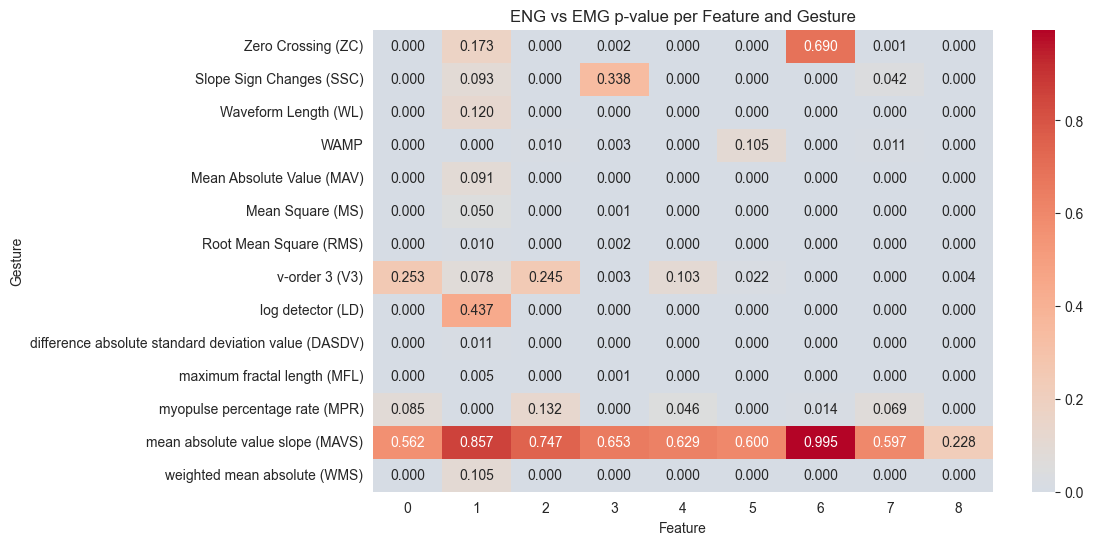

In [4]:
base_path = 'C:/Users/hml76/PycharmProjects/MindForce/data/EMG_ENG/'
all_subject = []

df = get_T_test_matrix(ENG_HM, ENG_HM_y, EMG_HM, EMG_HM_y)
heatmap_vis(df.T)

In [5]:
from scipy.stats import ttest_rel
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ---------------------------
# Cohen's d + Significance star
# ---------------------------
def cohens_d(x, y):
    nx, ny = len(x), len(y)
    dof = nx + ny - 2
    pooled_std = np.sqrt(((nx-1)*np.var(x, ddof=1) + (ny-1)*np.var(y, ddof=1)) / dof)
    return (np.mean(x) - np.mean(y)) / pooled_std

def significance_stars(p):
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    else:
        return ''

# ---------------------------
# Gesture × Feature T-test matrix
# ---------------------------
def get_T_test_matrix(X_ENG, y_ENG, X_EMG, y_EMG, feature_names):
    gestures = np.unique(y_EMG)
    print(gestures)
    results = []

    for g in gestures:
        idx_emg = np.where(y_EMG == g)[0]
        idx_eng = np.where(y_ENG == g)[0]

        Xg_emg = X_EMG[idx_emg]
        Xg_eng = X_ENG[idx_eng]

        for f, fname in enumerate(feature_names):
            # 채널별 RMS summary
            data_emg = np.sqrt(np.mean(Xg_emg[:, :, f]**2, axis=1))
            data_eng = np.sqrt(np.mean(Xg_eng[:, :, f]**2, axis=1))

            # paired t-test (샘플 수 맞추기)
            min_len = min(len(data_emg), len(data_eng))
            t_stat, p_val = ttest_rel(data_emg[:min_len], data_eng[:min_len])

            # Cohen's d
            d_val = cohens_d(data_eng[:min_len], data_emg[:min_len])

            # 평균 ± std
            mean_sd_emg = f"{data_emg[:min_len].mean():.2f} ± {data_emg[:min_len].std():.2f}"
            mean_sd_eng = f"{data_eng[:min_len].mean():.2f} ± {data_eng[:min_len].std():.2f}"

            results.append([int(fname), g, mean_sd_eng, mean_sd_emg, p_val, d_val])

    df = pd.DataFrame(results, columns=["Feature", "Gesture", "ENG (Mean±SD)", "EMG (Mean±SD)", "p-value", "Cohen_d"])
    df["Feature"] = df["Feature"].astype(int)  # 숫자형 보장

    return df

# ---------------------------
# Heatmap 시각화
# ---------------------------
def heatmap_vis(df):
    df_effect = df.pivot(index='Feature', columns='Gesture', values='Cohen_d').sort_index()
    df_pval = df.pivot(index='Feature', columns='Gesture', values='p-value').sort_index()

    annot = df_effect.round(2).astype(str)
    for i in range(df_effect.shape[0]):
        for j in range(df_effect.shape[1]):
            annot.iloc[i, j] += significance_stars(df_pval.iloc[i, j])

    plt.figure(figsize=(6,6), dpi=300)
    sns.heatmap(df_effect, annot=annot, fmt='', cmap='coolwarm', center=0,
                cbar_kws={'label': "Cohen's d"})
    plt.xlabel("Gesture class", fontsize=13)
    plt.ylabel("Feature index", fontsize=13)
    plt.xticks(rotation=0)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

In [43]:
pd.Series(EMG_HM_y).value_counts()

4    301
3    301
1    301
2    301
5    301
0    301
Name: count, dtype: int64

In [41]:
df = get_T_test_matrix(ENG_HM, ENG_HM_y, EMG_HM, EMG_HM_y, feature_names)

[0 1 2 3 4 5]


In [ ]:

# ---------------------------
# 예시 사용
# ---------------------------
feature_names = [f"{i+1}" for i in range(ENG_HM.shape[2])]
df = get_T_test_matrix(ENG_HM, ENG_HM_y, EMG_HM, EMG_HM_y, feature_names)
heatmap_vis(df)